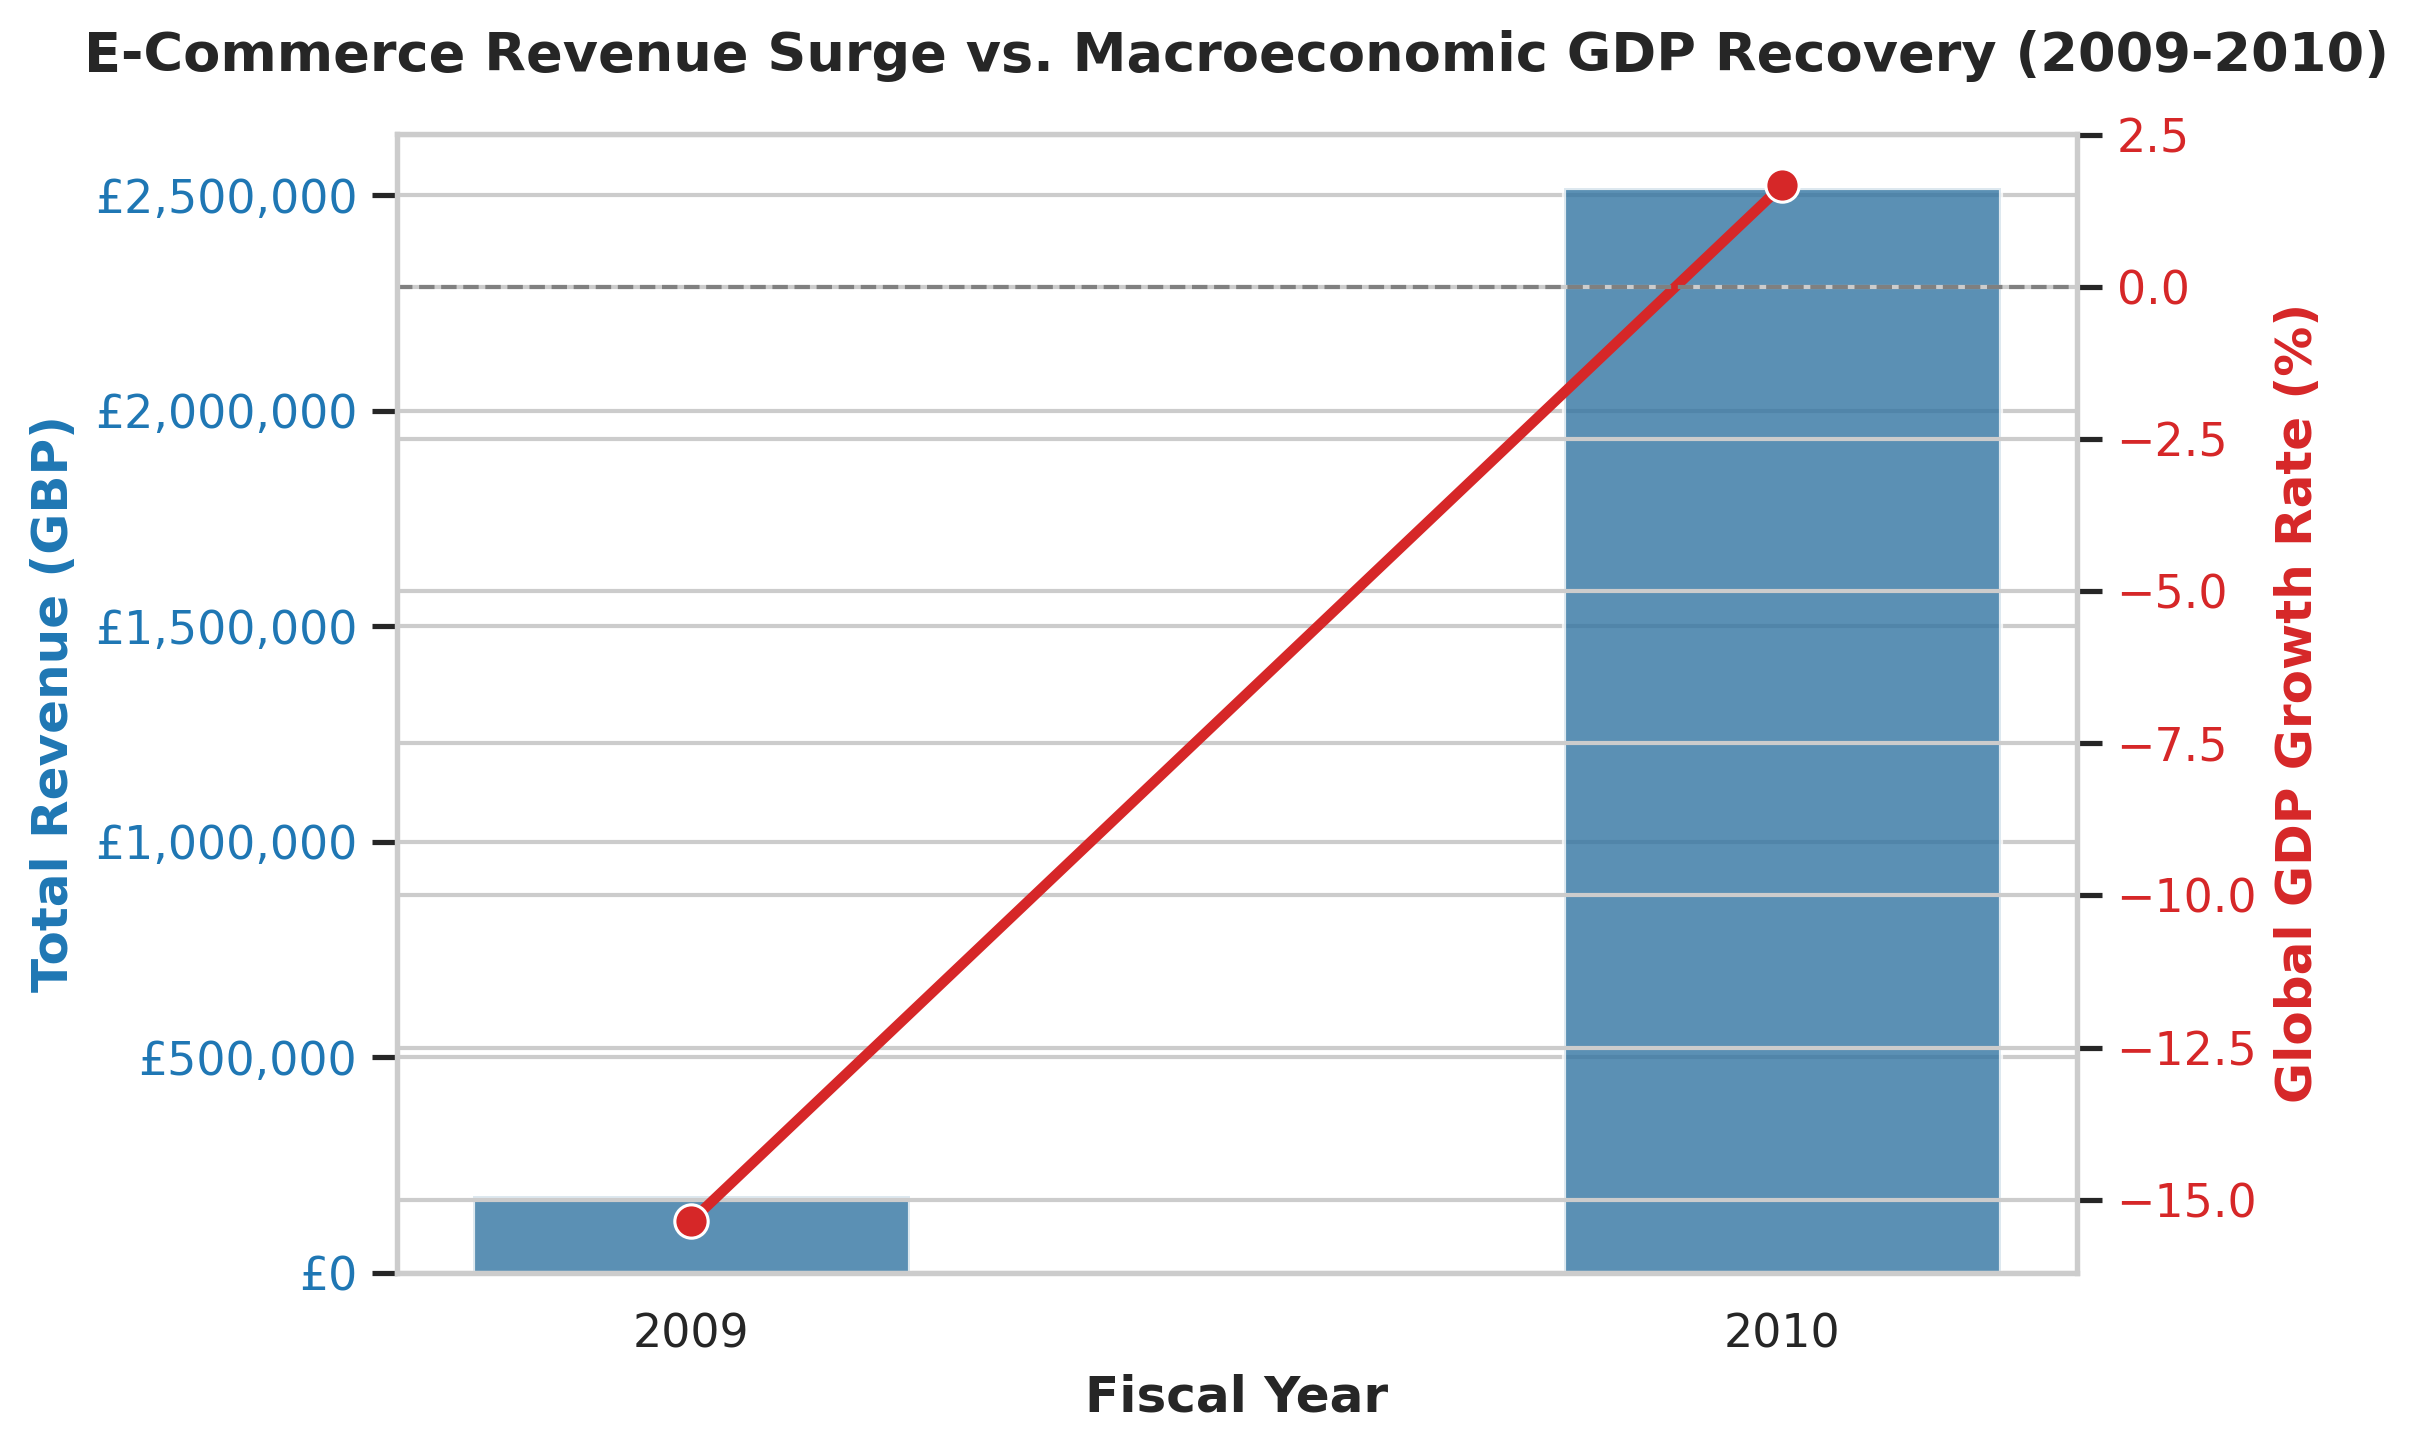

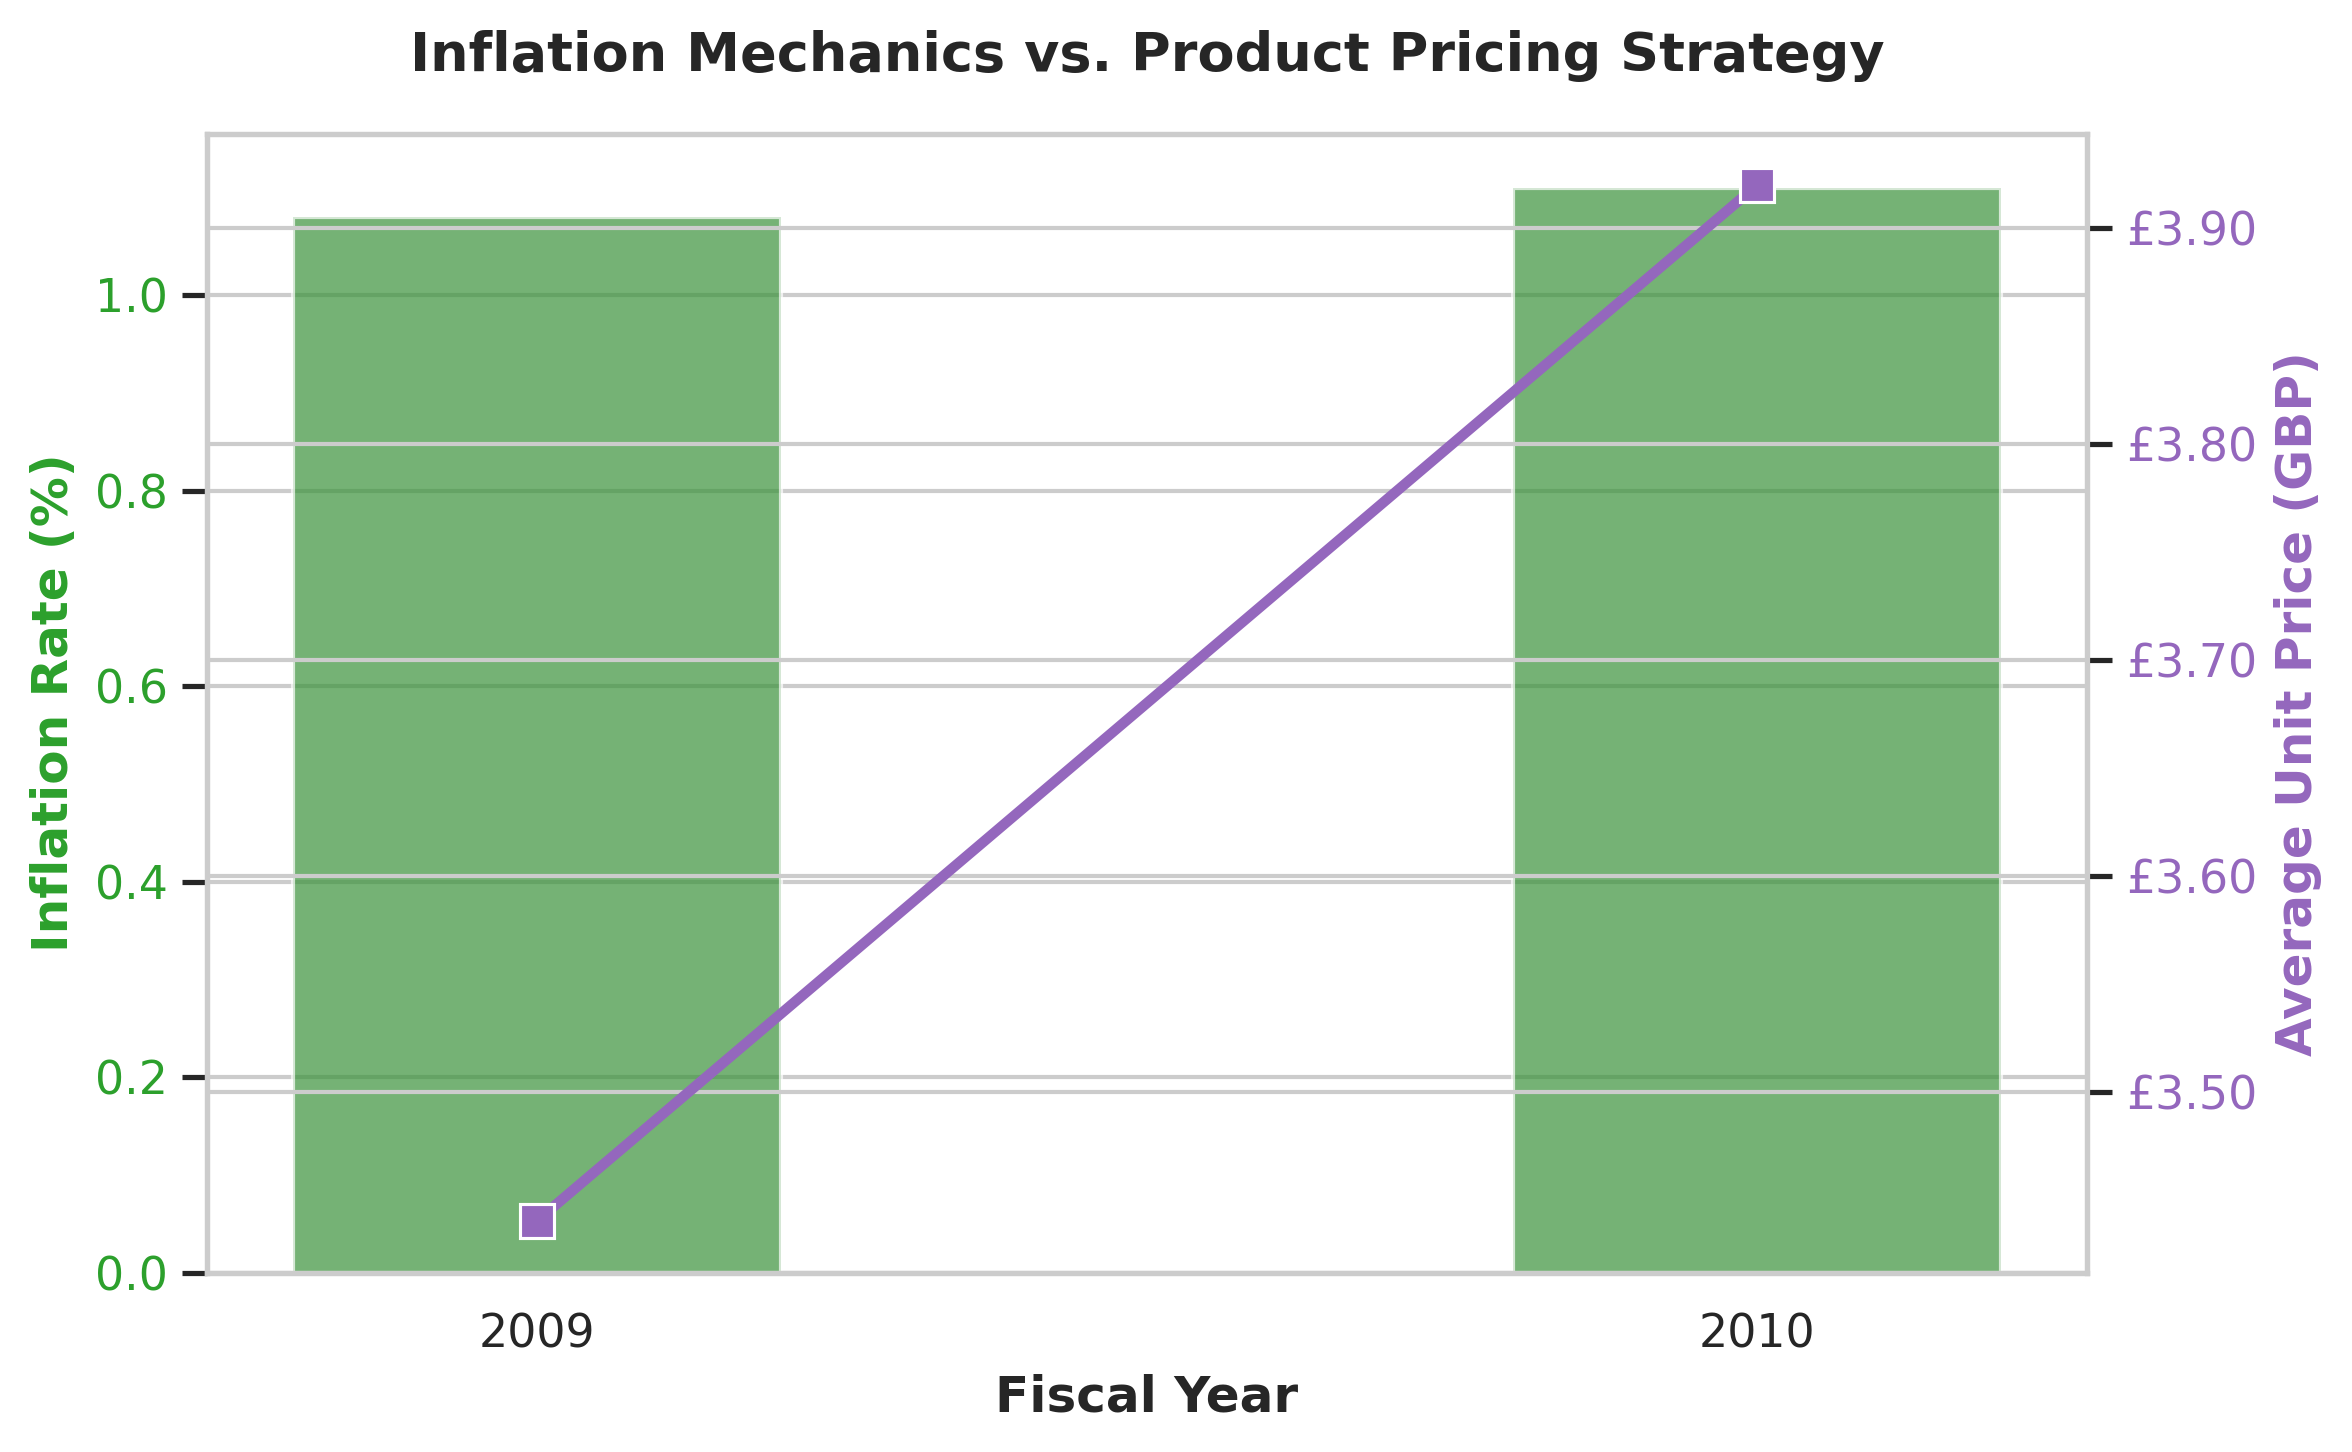

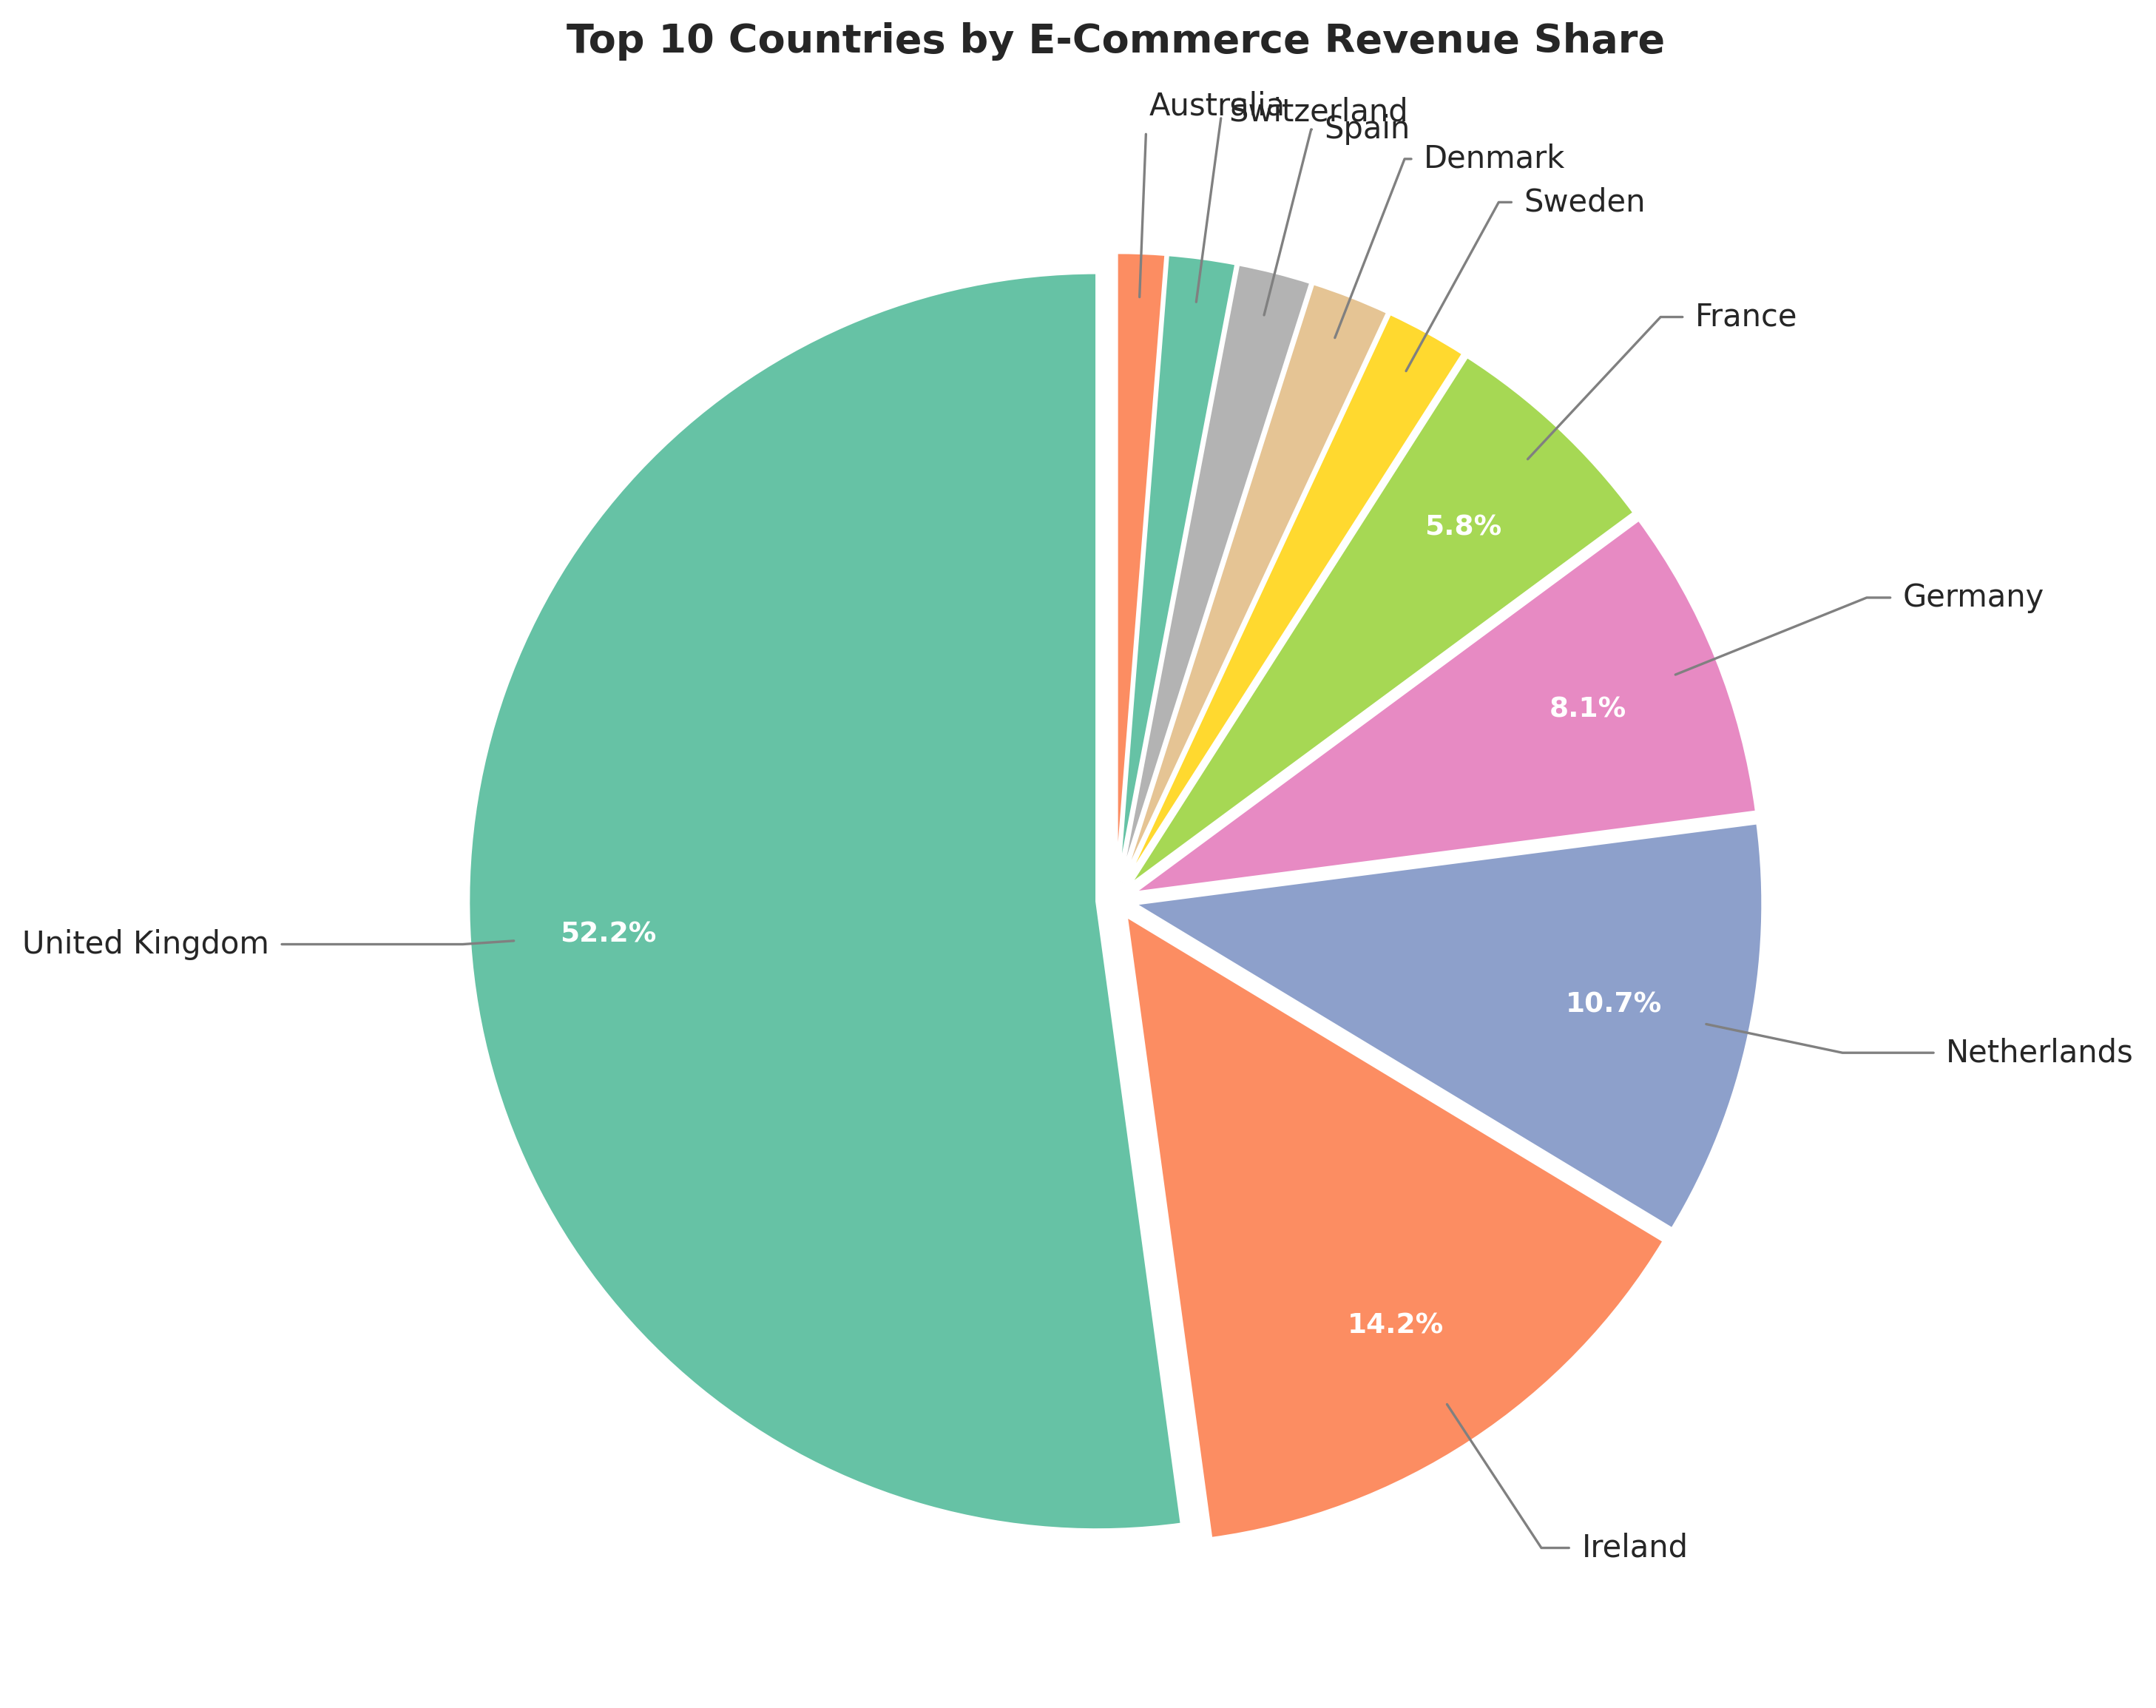

/tmp/ipykernel_586/3184876826.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Revenue_GBP', data=df_month, ax=ax, palette=bar_colors)


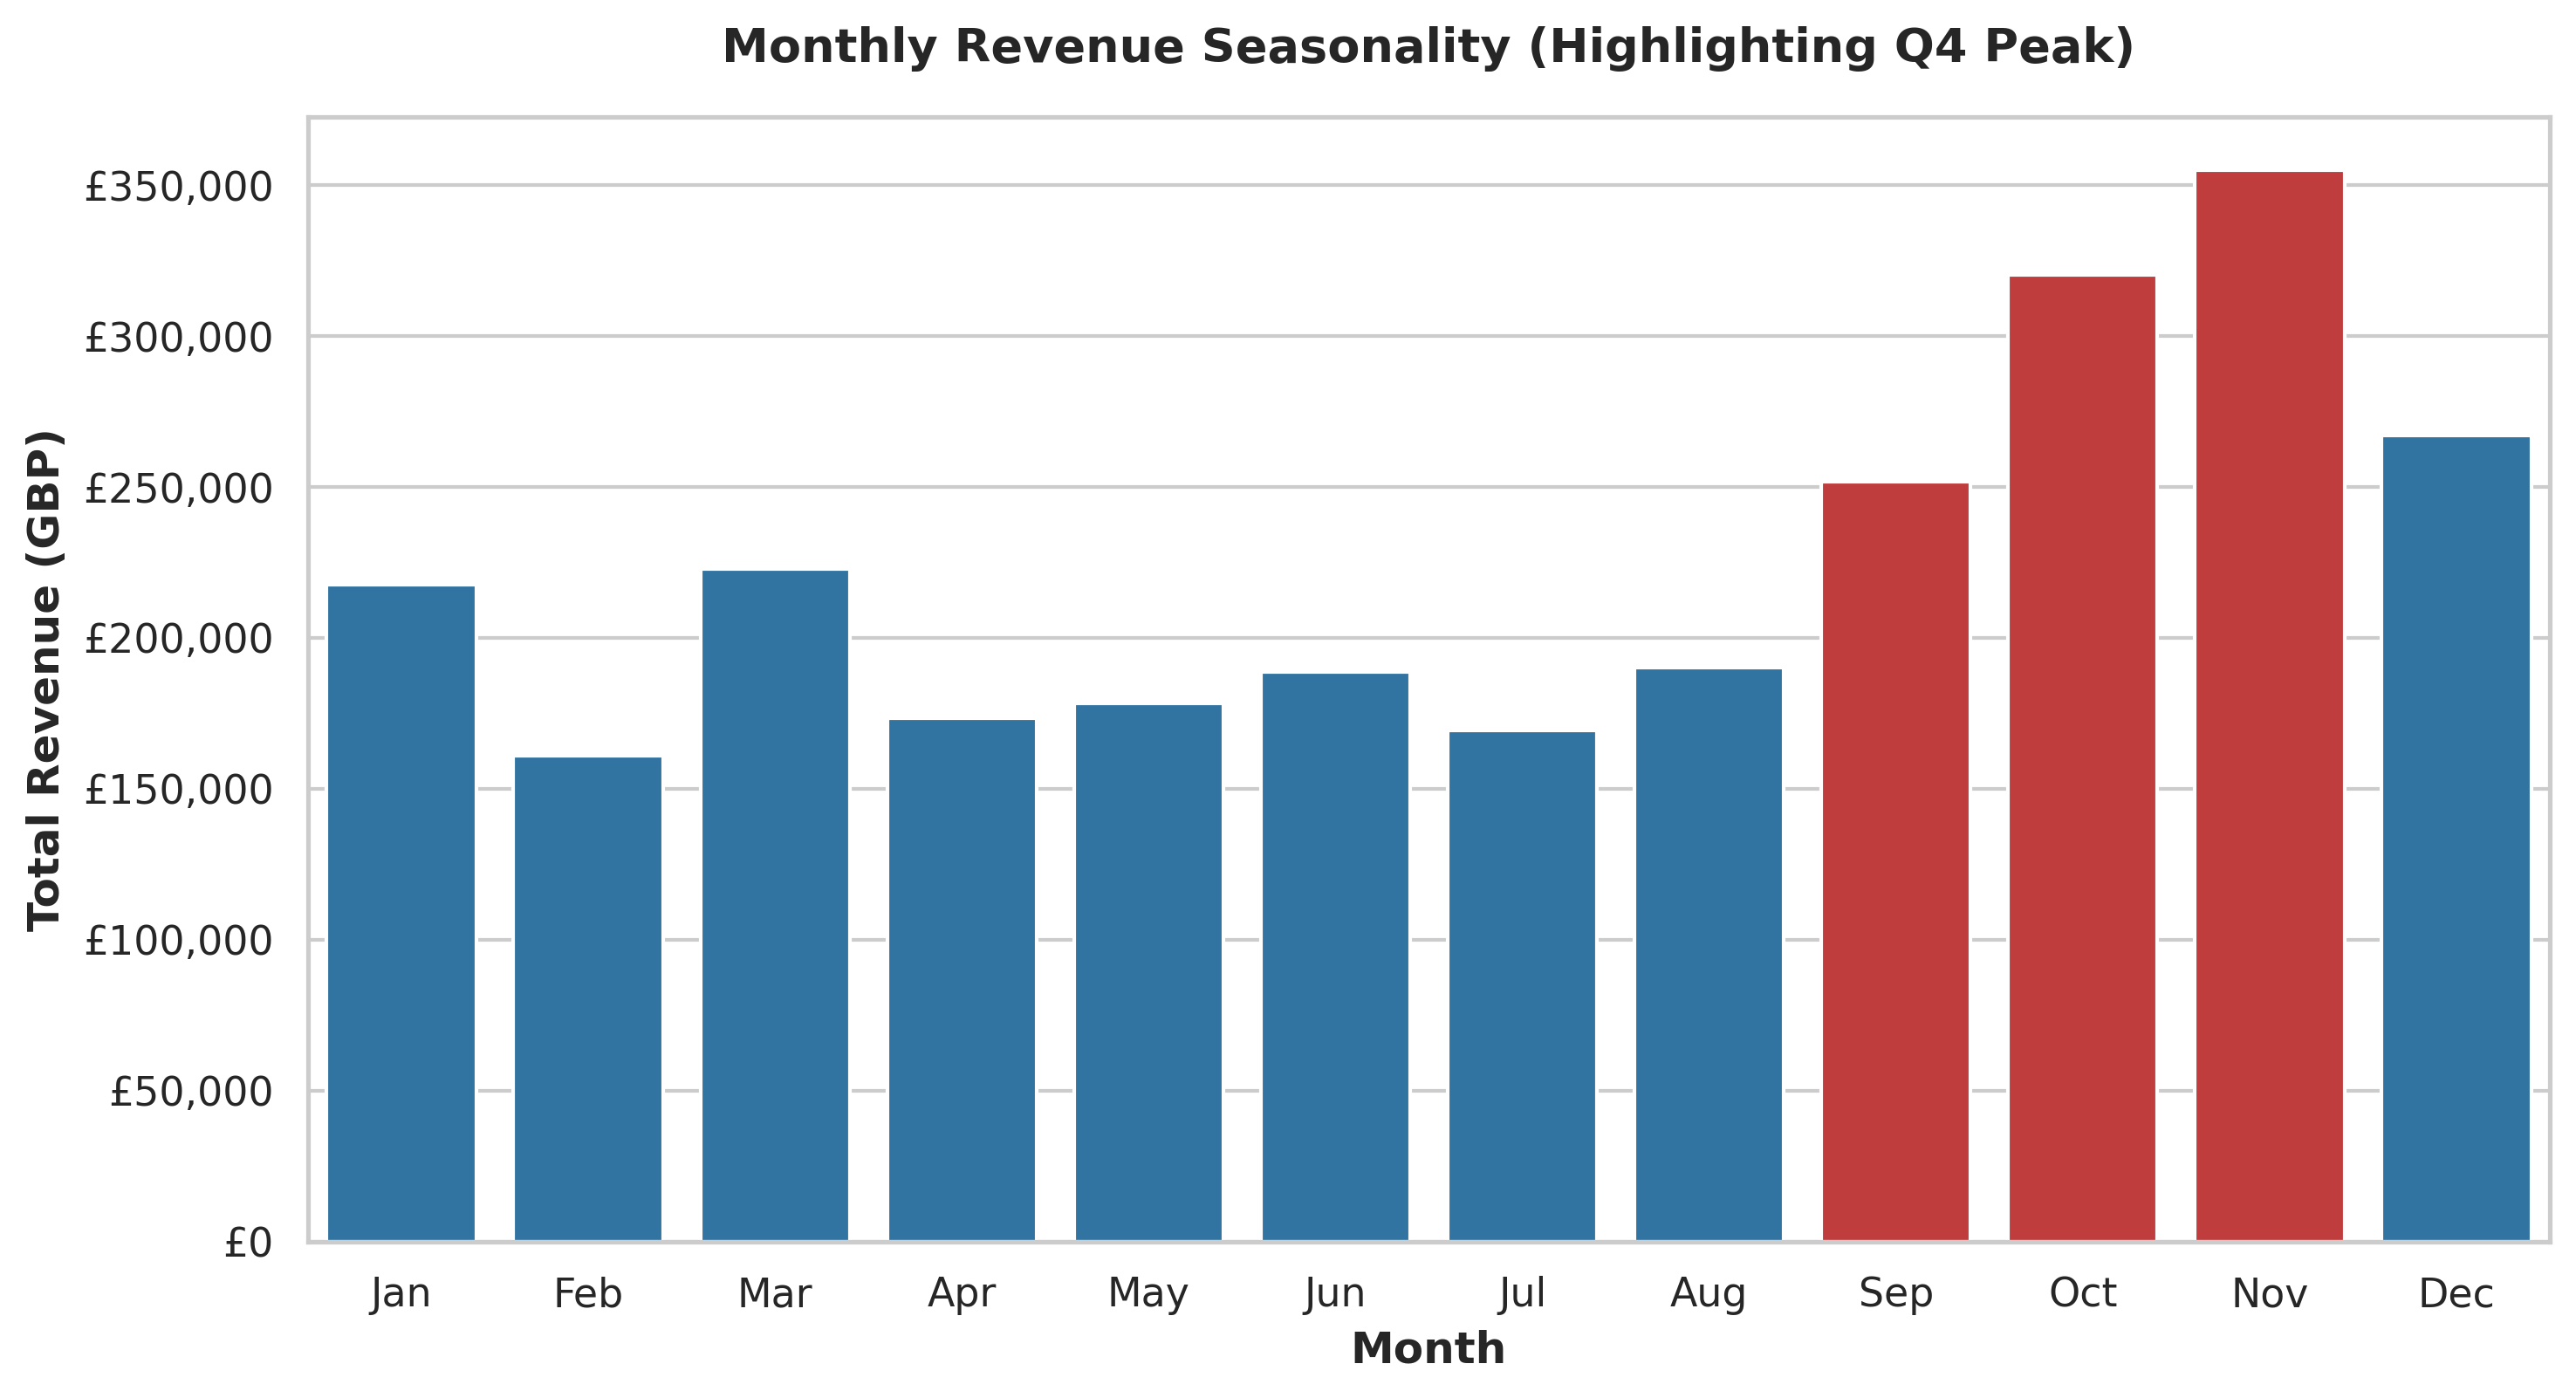

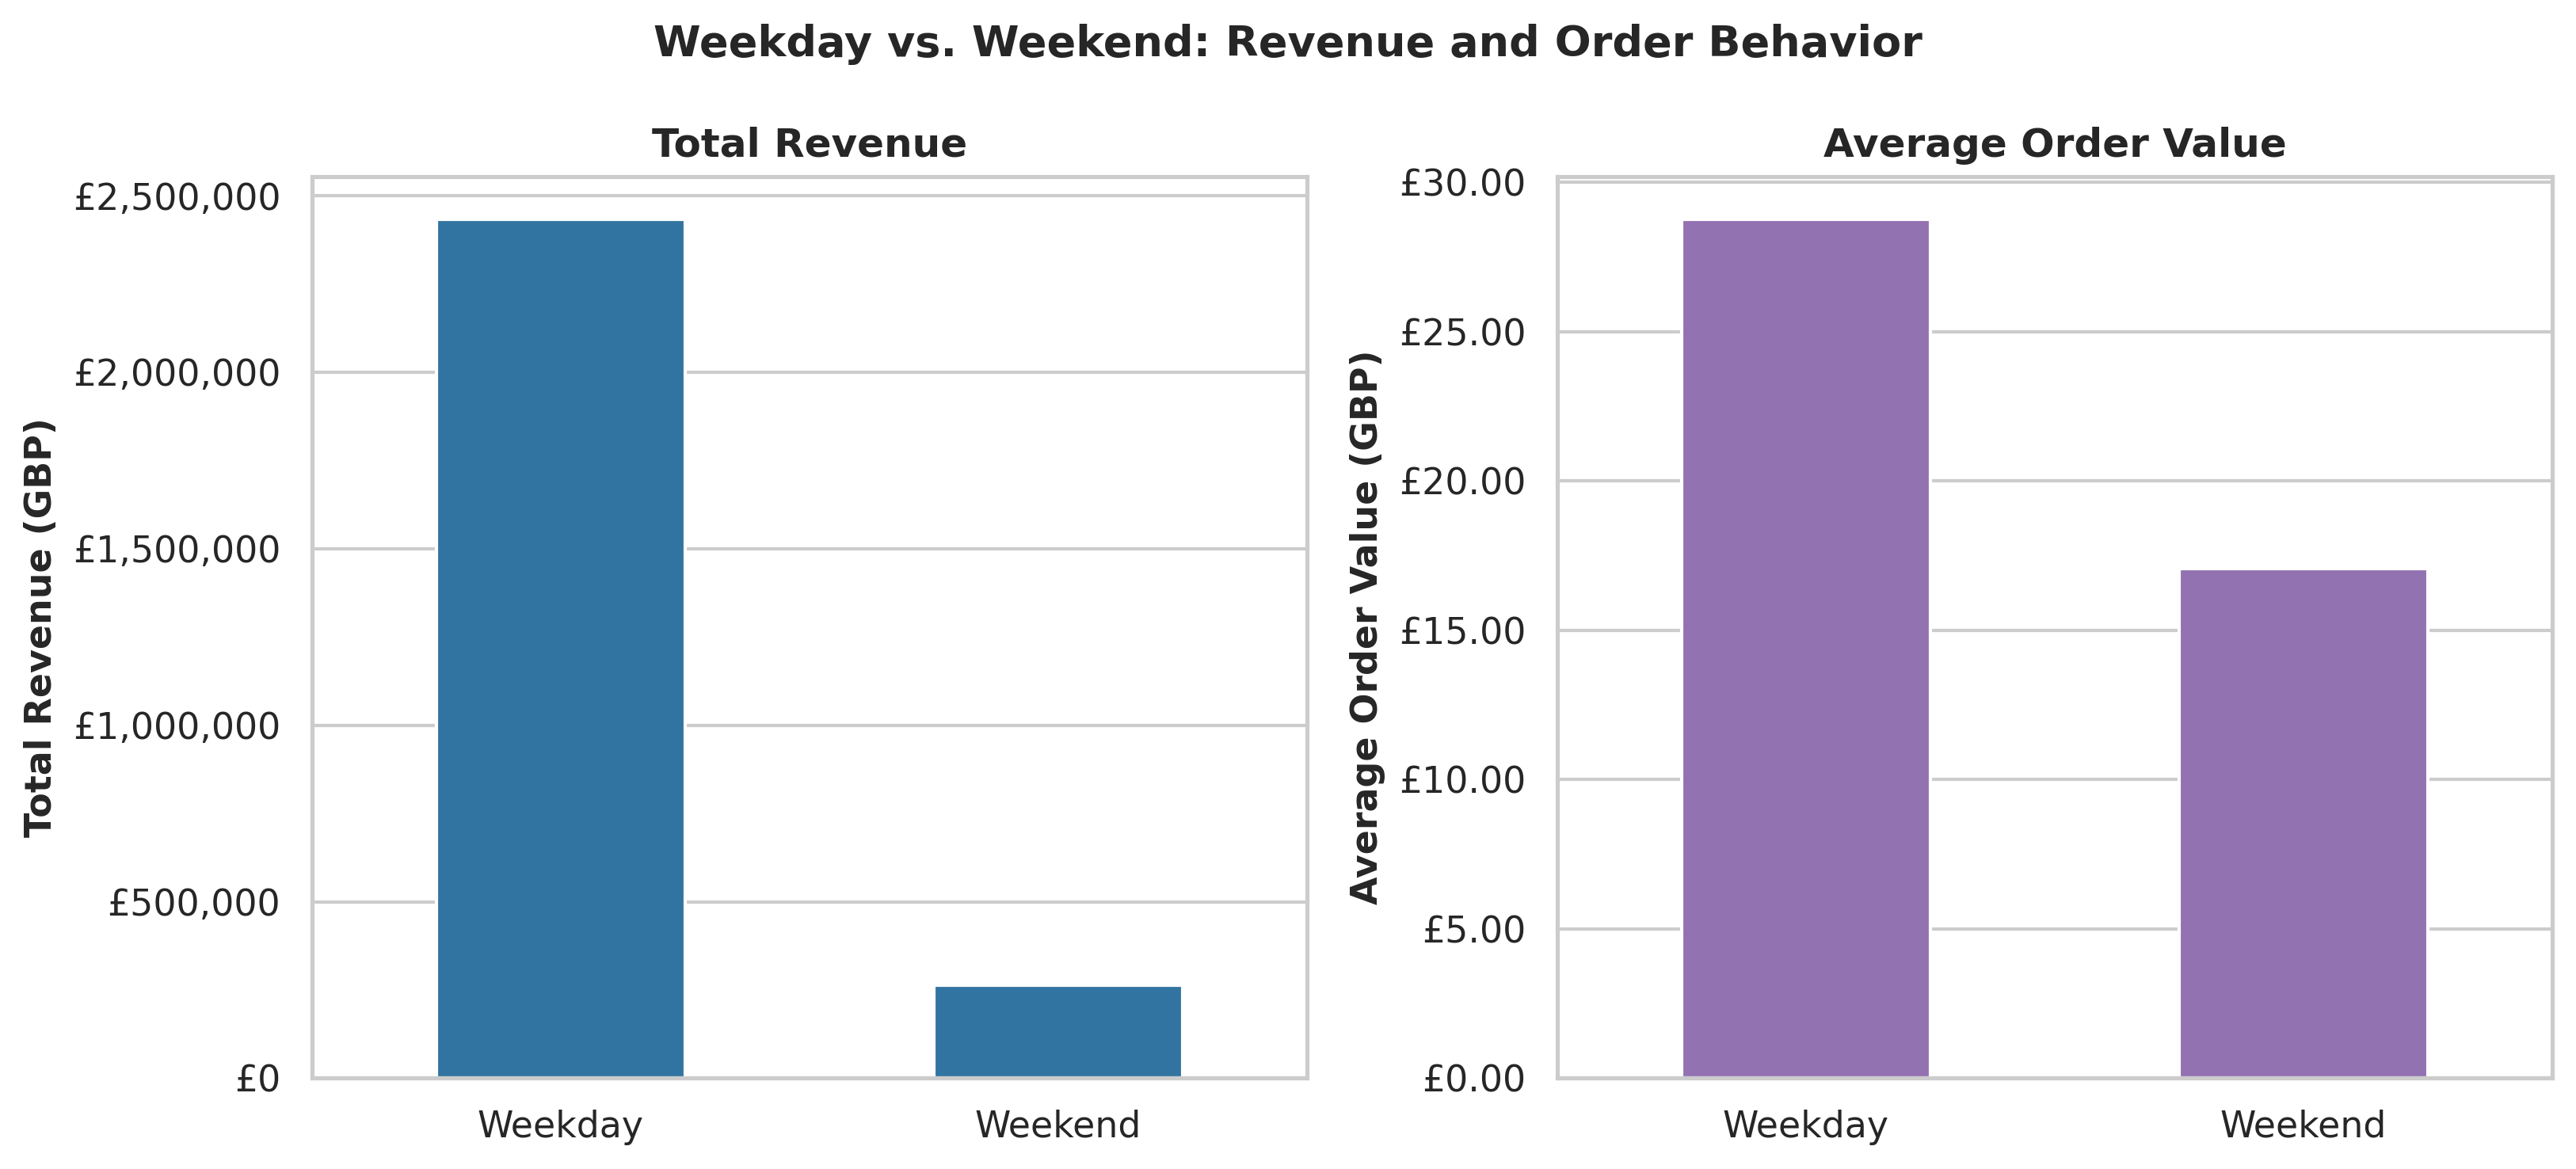

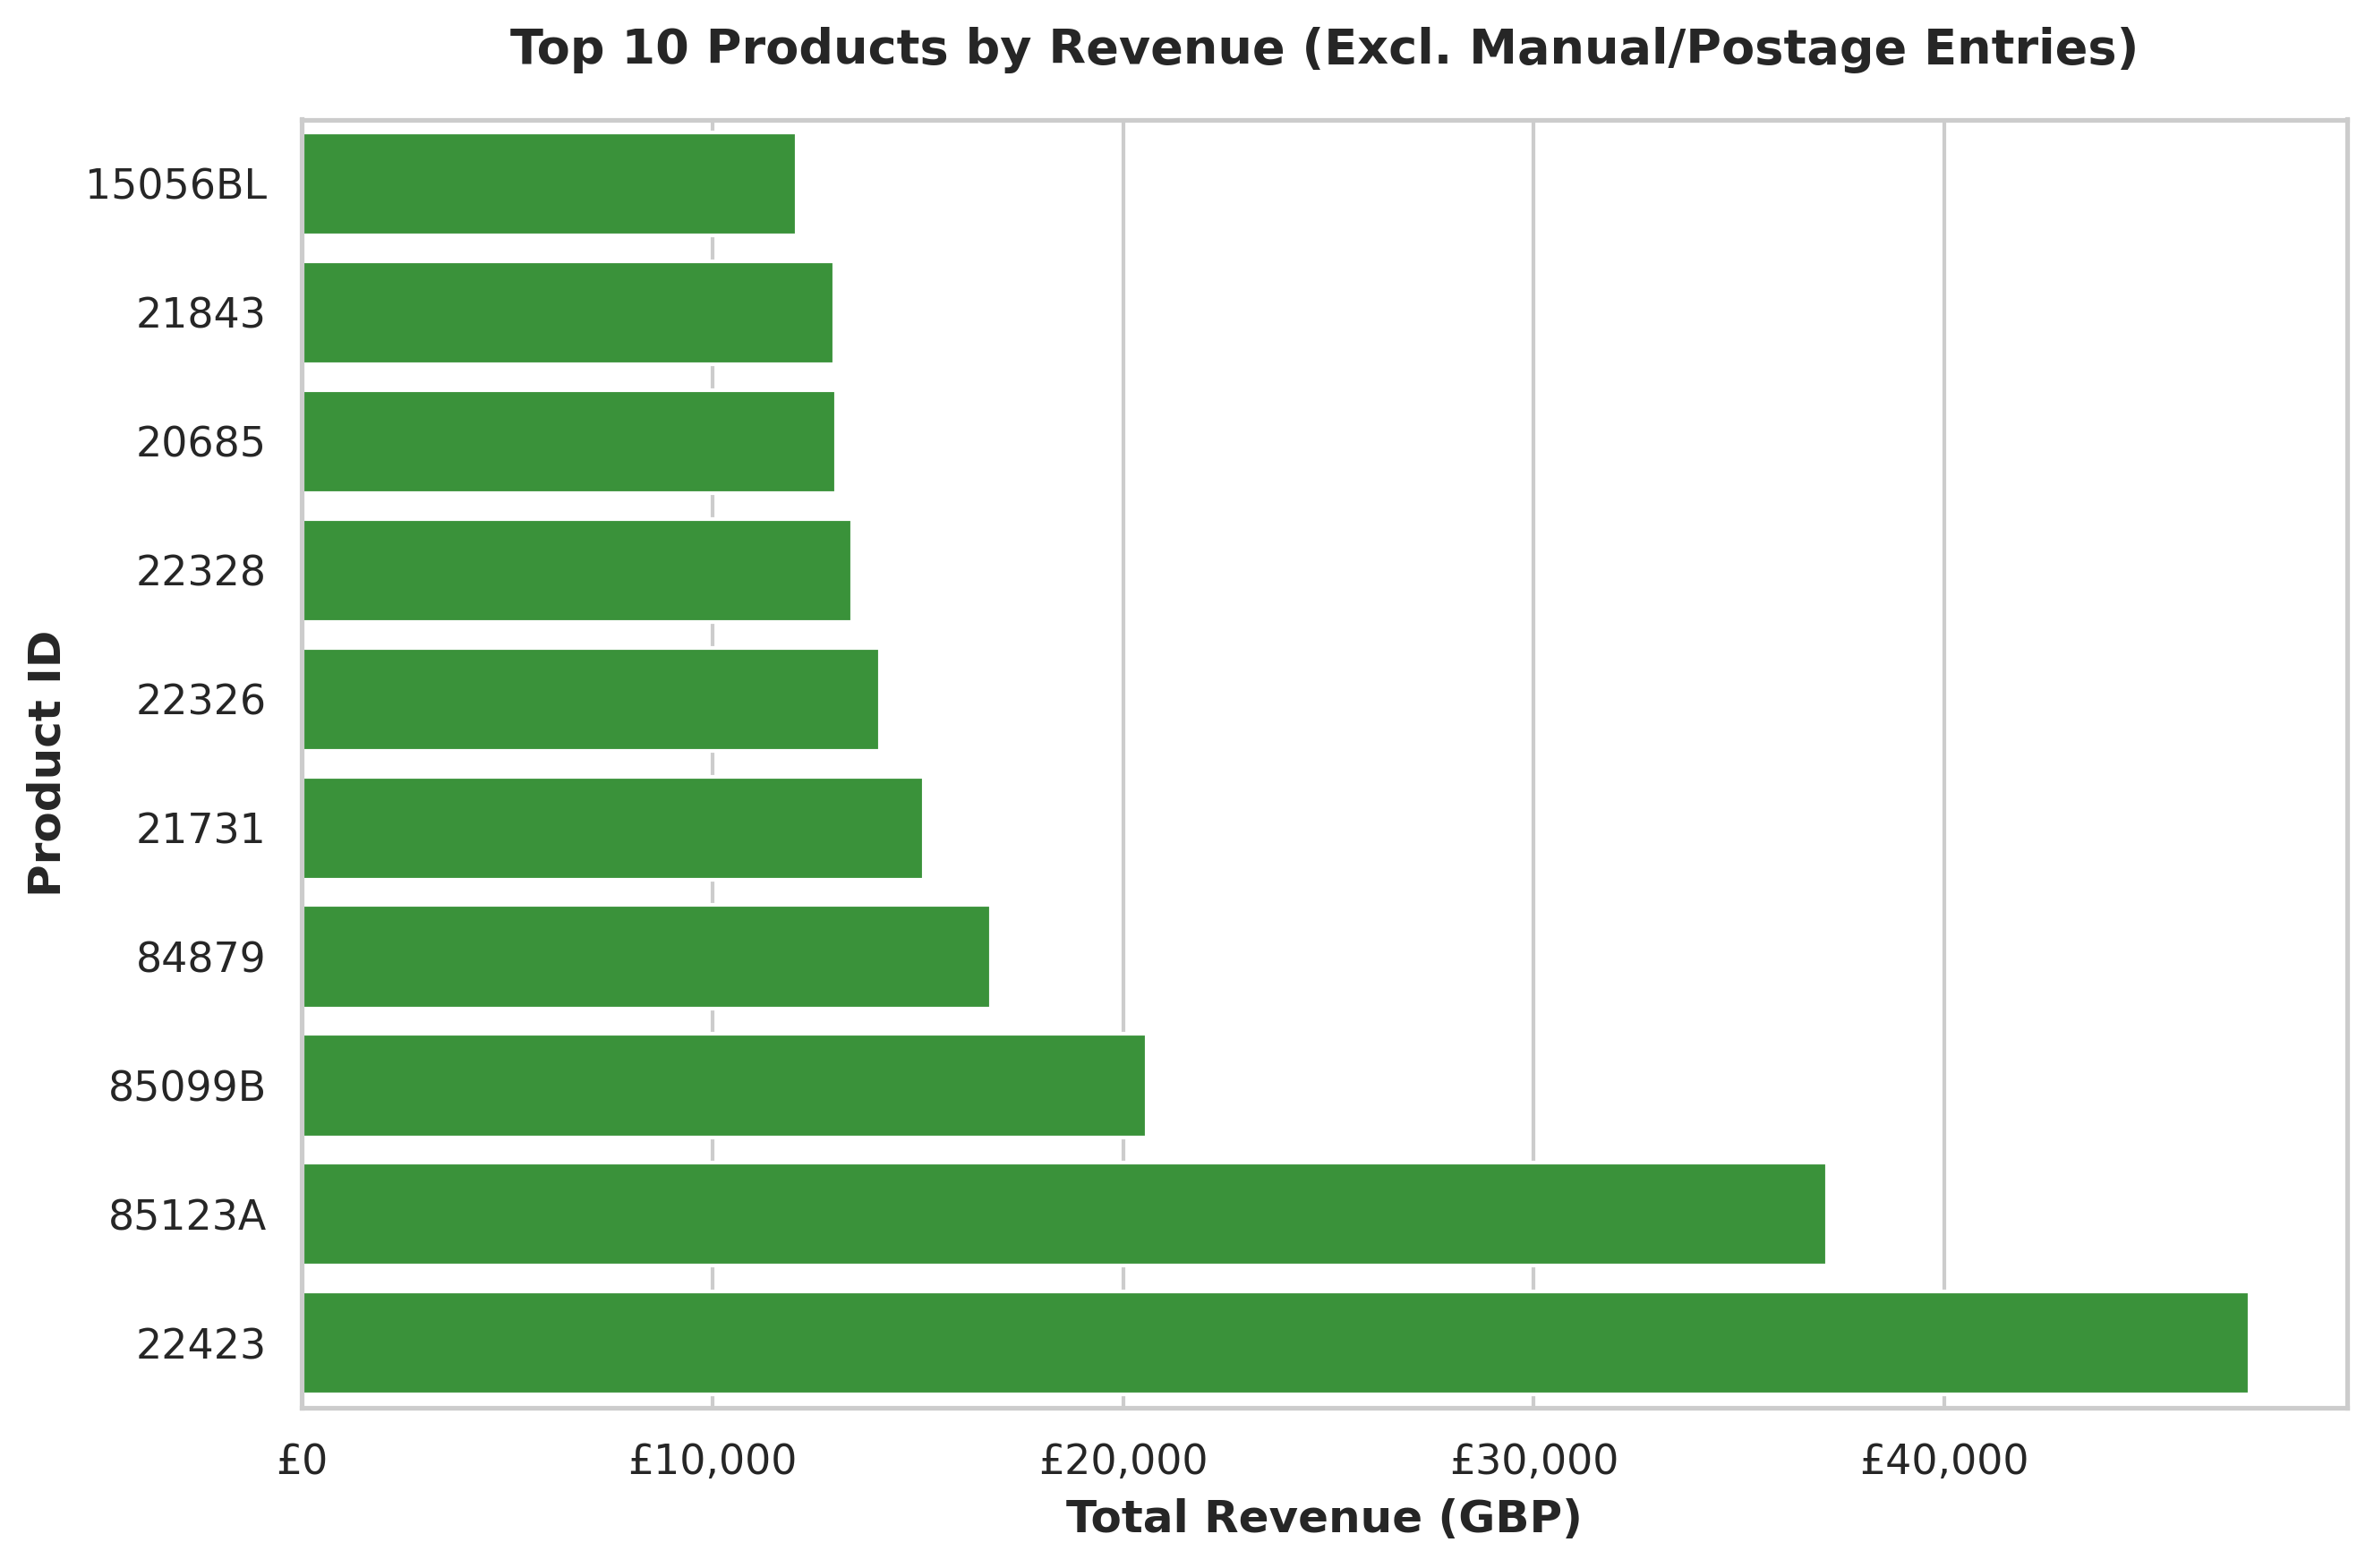

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. VISUALIZATION ENVIRONMENT CONFIGURATION
# ==============================================================================
# Set high-resolution output (300 DPI) for crisp, retina-ready graphics on GitHub
plt.rcParams['figure.dpi'] = 300
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# ==============================================================================
# 2. DATA INGESTION & STRUCTURING (Aggregated Metrics from Hive Engine)
# ==============================================================================
# Populating the dataset from the verified Hive aggregation query against
# ecommerce_db.cleaned_ecommerce_sales (raw_sales rebuilt with the correct
# 18-column schema and OpenCSVSerde to handle quoted fields, e.g. "Korea, Rep.").
# Query:
#   SELECT order_year, SUM(sales_value) AS total_revenue,
#          AVG(unit_price_gbp) AS avg_unit_price,
#          AVG(gdp_growth) AS avg_gdp_growth,
#          AVG(inflation_rate) AS avg_inflation
#   FROM ecommerce_db.cleaned_ecommerce_sales GROUP BY order_year;
data = {
    'Year': ['2009', '2010'],
    'Total_Revenue_GBP': [177586.37, 2517305.34],   # Verified via Hive SUM(sales_value)
    'GDP_Growth_Pct': [-15.35, 1.67],                # Verified via Hive AVG(gdp_growth)
    'Inflation_Rate_Pct': [1.08, 1.11],              # Verified via Hive AVG(inflation_rate)
    'Avg_Unit_Price_GBP': [3.44, 3.92]               # Verified via Hive AVG(unit_price_gbp)
}
df = pd.DataFrame(data)

# ==============================================================================
# CHART 1: DUAL-AXIS LINEAR CORRELATION (E-Commerce Revenue vs. Macro GDP)
# Objective: Illustrate the V-shaped economic recovery lagging with the 8x sales surge
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Primary Axis: Total Revenue (Bar Chart)
revenue_color = '#1f77b4'
sns.barplot(x='Year', y='Total_Revenue_GBP', data=df, ax=ax1, color=revenue_color, alpha=0.8, width=0.4)
ax1.set_xlabel('Fiscal Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Revenue (GBP)', color=revenue_color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=revenue_color)
# Format currency values nicely on the Y-axis
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

# Instantiate Secondary Axis: Global GDP Growth (Line Chart)
ax2 = ax1.twinx()
gdp_color = '#d62728'
sns.lineplot(x=['2009', '2010'], y='GDP_Growth_Pct', data=df, ax=ax2, color=gdp_color, marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Global GDP Growth Rate (%)', color=gdp_color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=gdp_color)
# Draw a baseline at 0% to clearly separate economic contraction from expansion
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title('E-Commerce Revenue Surge vs. Macroeconomic GDP Recovery (2009-2010)', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()

# Export high-fidelity PNG to the local workspace for GitHub documentation
plt.savefig('revenue_vs_gdp_hd.png', dpi=300)
plt.show()


# ==============================================================================
# CHART 2: RISK PRESSURE ANALYSIS (Inflation Mechanics vs. Pricing Strategy)
# Objective: Investigate if the volume explosion was driven by pricing elasticity
# ==============================================================================
fig, ax3 = plt.subplots(figsize=(8, 5))

# Plot Primary Axis: Inflation Rate Trend (Bar Chart)
inflation_color = '#2ca02c'
sns.barplot(x='Year', y='Inflation_Rate_Pct', data=df, ax=ax3, color=inflation_color, alpha=0.7, width=0.4)
ax3.set_xlabel('Fiscal Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Inflation Rate (%)', color=inflation_color, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=inflation_color)

# Instantiate Secondary Axis: Product Pricing Velocity (Line Chart)
ax4 = ax3.twinx()
price_color = '#9467bd'
sns.lineplot(x=['2009', '2010'], y='Avg_Unit_Price_GBP', data=df, ax=ax4, color=price_color, marker='s', linewidth=2.5, markersize=8)
ax4.set_ylabel('Average Unit Price (GBP)', color=price_color, fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor=price_color)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:.2f}'))

plt.title('Inflation Mechanics vs. Product Pricing Strategy', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()

# Export high-fidelity PNG to the local workspace for GitHub documentation
plt.savefig('inflation_vs_pricing_hd.png', dpi=300)
plt.show()
# ==============================================================================
# CHART 3: TOP 10 COUNTRIES BY REVENUE (Pie Chart)
# Source query (Hive):
#   SELECT country, SUM(sales_value) AS total_revenue
#   FROM ecommerce_db.cleaned_ecommerce_sales
#   GROUP BY country ORDER BY total_revenue DESC LIMIT 10;
# ==============================================================================
country_data = {
    'Country': ['United Kingdom', 'Ireland', 'Netherlands', 'Germany', 'France',
                'Sweden', 'Denmark', 'Spain', 'Switzerland', 'Australia'],
    'Revenue_GBP': [1308673.71, 356085.21, 268786.00, 202395.32, 146215.42,
                    53171.39, 50906.85, 47601.42, 43921.39, 31446.80]
}
df_country = pd.DataFrame(country_data)

fig, ax = plt.subplots(figsize=(9, 8))
colors = sns.color_palette('Set2', n_colors=len(df_country))
explode = [0.03] * len(df_country)

wedges, texts, autotexts = ax.pie(
    df_country['Revenue_GBP'],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    colors=colors,
    explode=explode,
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 10}
)
plt.setp(autotexts, size=9, weight='bold', color='white')

# Use leader-line annotations instead of plain labels to avoid overlap on small wedges
for i, wedge in enumerate(wedges):
    ang = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    horizontalalignment = 'left' if x >= 0 else 'right'
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    ax.annotate(
        df_country['Country'].iloc[i],
        xy=(x * 0.95, y * 0.95),
        xytext=(x * 1.35, y * 1.25),
        horizontalalignment=horizontalalignment,
        fontsize=10,
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray', lw=0.8)
    )

ax.set_title('Top 10 Countries by E-Commerce Revenue Share', fontsize=13, fontweight='bold', pad=20)
fig.tight_layout()
plt.savefig('top_countries_pie.png', dpi=300, bbox_inches='tight')
plt.show()


# ==============================================================================
# CHART 4: MONTHLY REVENUE SEASONALITY (Bar Chart)
# Source query (Hive):
#   SELECT order_month, SUM(sales_value) AS total_revenue
#   FROM ecommerce_db.cleaned_ecommerce_sales
#   GROUP BY order_month ORDER BY order_month;
# ==============================================================================
month_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Revenue_GBP': [217705.05, 160845.37, 222797.05, 173373.56, 178228.51, 188582.66,
                    169401.90, 190037.90, 251746.74, 320149.81, 354997.91, 267025.25]
}
df_month = pd.DataFrame(month_data)

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_colors = ['#d62728' if m in ['Sep', 'Oct', 'Nov'] else '#1f77b4' for m in df_month['Month']]
sns.barplot(x='Month', y='Revenue_GBP', data=df_month, ax=ax, palette=bar_colors)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue (GBP)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.set_title('Monthly Revenue Seasonality (Highlighting Q4 Peak)', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('monthly_seasonality.png', dpi=300)
plt.show()


# ==============================================================================
# CHART 5: WEEKDAY VS WEEKEND REVENUE & ORDER BEHAVIOR (Bar Chart)
# Source query (Hive):
#   SELECT is_weekend, SUM(sales_value) AS total_revenue, COUNT(*) AS num_orders,
#          AVG(sales_value) AS avg_order_value
#   FROM ecommerce_db.cleaned_ecommerce_sales
#   GROUP BY is_weekend;
# ==============================================================================
weekday_data = {
    'Day_Type': ['Weekday', 'Weekend'],
    'Total_Revenue_GBP': [2432328.35, 262563.36],
    'Num_Orders': [84604, 15396],
    'Avg_Order_Value_GBP': [28.75, 17.05]
}
df_weekday = pd.DataFrame(weekday_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

sns.barplot(x='Day_Type', y='Total_Revenue_GBP', data=df_weekday, ax=ax1, color='#1f77b4', width=0.5)
ax1.set_ylabel('Total Revenue (GBP)', fontsize=11, fontweight='bold')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax1.set_title('Total Revenue', fontsize=12, fontweight='bold')

sns.barplot(x='Day_Type', y='Avg_Order_Value_GBP', data=df_weekday, ax=ax2, color='#9467bd', width=0.5)
ax2.set_ylabel('Average Order Value (GBP)', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:.2f}'))
ax2.set_title('Average Order Value', fontsize=12, fontweight='bold')

fig.suptitle('Weekday vs. Weekend: Revenue and Order Behavior', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=300)
plt.show()


# ==============================================================================
# CHART 6: TOP 10 PRODUCTS BY REVENUE (Horizontal Bar Chart)
# Non-product ledger entries ('M' = manual adjustment, 'POST' = postage/shipping
# fee line items) were excluded so the ranking reflects actual merchandise only.
# Source query (Hive):
#   SELECT product_id, SUM(CAST(sales_amount_gbp AS DOUBLE)) AS total_revenue,
#          SUM(CAST(quantity_sold AS INT)) AS total_qty
#   FROM ecommerce_db.raw_sales
#   WHERE order_datetime IS NOT NULL AND order_datetime != ''
#     AND product_id NOT IN ('M', 'POST')
#   GROUP BY product_id ORDER BY total_revenue DESC LIMIT 10;
# ==============================================================================
product_data = {
    'Product_ID': ['22423', '85123A', '85099B', '84879', '21731',
                    '22326', '22328', '20685', '21843', '15056BL'],
    'Revenue_GBP': [47434.80, 37131.60, 20564.25, 16787.36, 15144.45,
                    14069.10, 13398.30, 12999.62, 12971.15, 12054.70]
}
df_product = pd.DataFrame(product_data).sort_values('Revenue_GBP')

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='Revenue_GBP', y='Product_ID', data=df_product, ax=ax, color='#2ca02c')
ax.set_xlabel('Total Revenue (GBP)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product ID', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.set_title('Top 10 Products by Revenue (Excl. Manual/Postage Entries)', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('top_products.png', dpi=300)
plt.show()
